In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [140]:
folder='/home/insauer/projects/hhrm/projects/TipESM/data/aggregated_results/cluster_runs/'

In [141]:
tipped_decile= pd.read_csv(folder + 'tipped_decile.csv')
tipped_n_events= pd.read_csv(folder + "tipped_n_events.csv")
tipped= pd.read_csv(folder + "tipped.csv")
weighted_avg_decile= pd.read_csv(folder + "weighted_avg_decile.csv")
overall_sum=pd.read_csv(folder +  "overall_sum.csv")
weighted_avg_event_decile= pd.read_csv(folder + "weighted_avg_event_decile.csv")

In [144]:
26*25

650

In [142]:
tipped

,not_tipped,tipped,model,ssp,wl,run
0,92681356.0,10339048.0,IPSL-CM6A-LR,ssp370,30,1
1,92254246.0,10766158.0,UKESM1-0-LL,ssp370,15,15
2,92449960.0,10570444.0,IPSL-CM6A-LR,ssp370,40,0
3,92590340.0,10430064.0,UKESM1-0-LL,ssp585,30,20
4,92690705.0,10329699.0,UKESM1-0-LL,ssp370,40,14
...,...,...,...,...,...,...
645,92654246.0,10366158.0,IPSL-CM6A-LR,ssp126,10,5
646,91728086.0,11292318.0,IPSL-CM6A-LR,ssp585,30,14
647,92454605.0,10565799.0,UKESM1-0-LL,ssp370,30,19
648,92499217.0,10521187.0,UKESM1-0-LL,ssp370,30,20


In [190]:
agg_25

,wl_float,tipped,not_tipped,share_tipped
0,1.0,10310699.7,92390290.1,0.100395
1,1.5,10323633.0,92180686.0,0.100714
2,2.0,10322699.2,92019167.4,0.100865
3,3.0,10344161.6,92109369.9,0.100964
4,4.0,10370436.5,91655417.9,0.101645


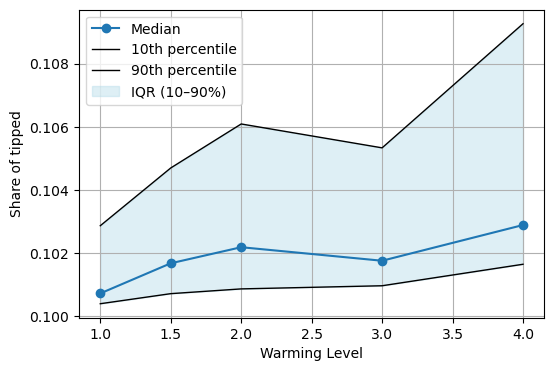

In [160]:

# --- Step 1: Convert wl to float and divide by 10 ---
tipped["wl_float"] = tipped["wl"].astype(float) / 10

# --- Step 2: Aggregate over wl ---
agg = tipped.groupby("wl_float")[["tipped", "not_tipped"]].median().reset_index()
agg_25 = (
    tipped
    .groupby("wl_float")[["tipped", "not_tipped"]]
    .agg(lambda x: x.quantile(0.1))
    .reset_index()
)

agg_75 = (
    tipped
    .groupby("wl_float")[["tipped", "not_tipped"]]
    .agg(lambda x: x.quantile(0.9))
    .reset_index()
)

# --- Step 3: Compute share of tipped ---
agg["share_tipped"] = agg["tipped"] / (agg["tipped"] + agg["not_tipped"])
agg_25["share_tipped"] = agg_25["tipped"] / (agg_25["tipped"] + agg_25["not_tipped"])
agg_75["share_tipped"] = agg_75["tipped"] / (agg_75["tipped"] + agg_75["not_tipped"])
# --- Step 4: Plot ---
plt.figure(figsize=(6,4))

# Main line (mean)
plt.plot(agg["wl_float"], agg["share_tipped"], marker='o', label="Median")

# Percentile lines (small black lines)
plt.plot(agg_25["wl_float"], agg_25["share_tipped"], color="black", linewidth=1, label="10th percentile")
plt.plot(agg_75["wl_float"], agg_75["share_tipped"], color="black", linewidth=1, label="90th percentile")

# Fill between percentiles
plt.fill_between(
    agg["wl_float"],
    agg_25["share_tipped"],
    agg_75["share_tipped"],
    color="lightblue",
    alpha=0.4,
    label="IQR (10–90%)"
)

plt.xlabel("Warming Level")
plt.ylabel("Share of tipped")
plt.grid(True)
plt.legend()
plt.show()
#plt.savefig('/home/insauer/projects/hhrm/projects/TipESM/data/final_plots/PHL/overall_tipped.png')

In [136]:
tipped_decile

,decile,not_tipped,tipped,model,ssp,wl,run
0,1,0.0,10302042.0,IPSL-CM6A-LR,ssp370,30,1
1,2,10283231.0,18790.0,IPSL-CM6A-LR,ssp370,30,1
2,3,10293662.0,8454.0,IPSL-CM6A-LR,ssp370,30,1
3,4,10295132.0,6818.0,IPSL-CM6A-LR,ssp370,30,1
4,5,10299145.0,2906.0,IPSL-CM6A-LR,ssp370,30,1
...,...,...,...,...,...,...,...
5125,6,10302068.0,31.0,GFDL-ESM4,ssp585,30,20
5126,7,10302034.0,1.0,GFDL-ESM4,ssp585,30,20
5127,8,10302106.0,0.0,GFDL-ESM4,ssp585,30,20
5128,9,10301976.0,0.0,GFDL-ESM4,ssp585,30,20


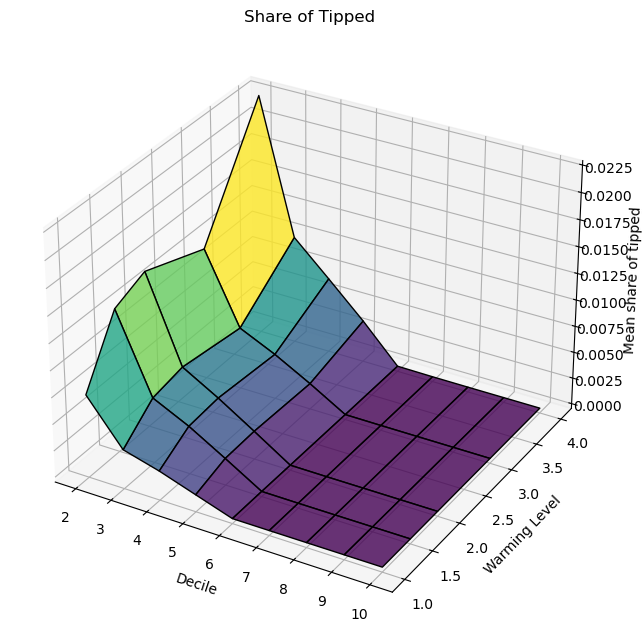

In [137]:

# Convert wl to float and scale
tipped_decile["wl_float"] = tipped_decile["wl"].astype(float) / 10

# Filter deciles >= 2
tipped_decile_filtered = tipped_decile[tipped_decile["decile"] >= 2]

# Aggregate by decile and wl taking mean
agg = tipped_decile_filtered.groupby(["decile", "wl_float"])[["tipped", "not_tipped"]].mean().reset_index()

# Compute share of tipped
agg["share_tipped"] = agg["tipped"] / (agg["tipped"] + agg["not_tipped"])

# Prepare grid for 3D plot
deciles = sorted(agg["decile"].unique())
wls = sorted(agg["wl_float"].unique())
decile_grid, wl_grid = np.meshgrid(deciles, wls, indexing='ij')

share_grid = np.zeros_like(decile_grid, dtype=float)
for i, dec in enumerate(deciles):
    for j, wl in enumerate(wls):
        val = agg.loc[(agg["decile"]==dec) & (agg["wl_float"]==wl), "share_tipped"]
        share_grid[i,j] = val.values[0] if not val.empty else np.nan

# Plot 3D surface with smaller axes relative to figure
fig = plt.figure(figsize=(10,10))
# Axes position: [left, bottom, width, height] all in figure fraction
ax = fig.add_axes([0.05, 0.2, 0.6, 0.6], projection='3d')

ax.plot_surface(decile_grid, wl_grid, share_grid, cmap='viridis', edgecolor='k', alpha=0.8)

ax.set_xlabel('Decile')
ax.set_ylabel('Warming Level')
ax.set_zlabel('Mean share of tipped')
ax.set_title('Share of Tipped')
#fig.savefig('/home/insauer/projects/hhrm/projects/TipESM/data/final_plots/PHL/tipped_decile_3d.png')

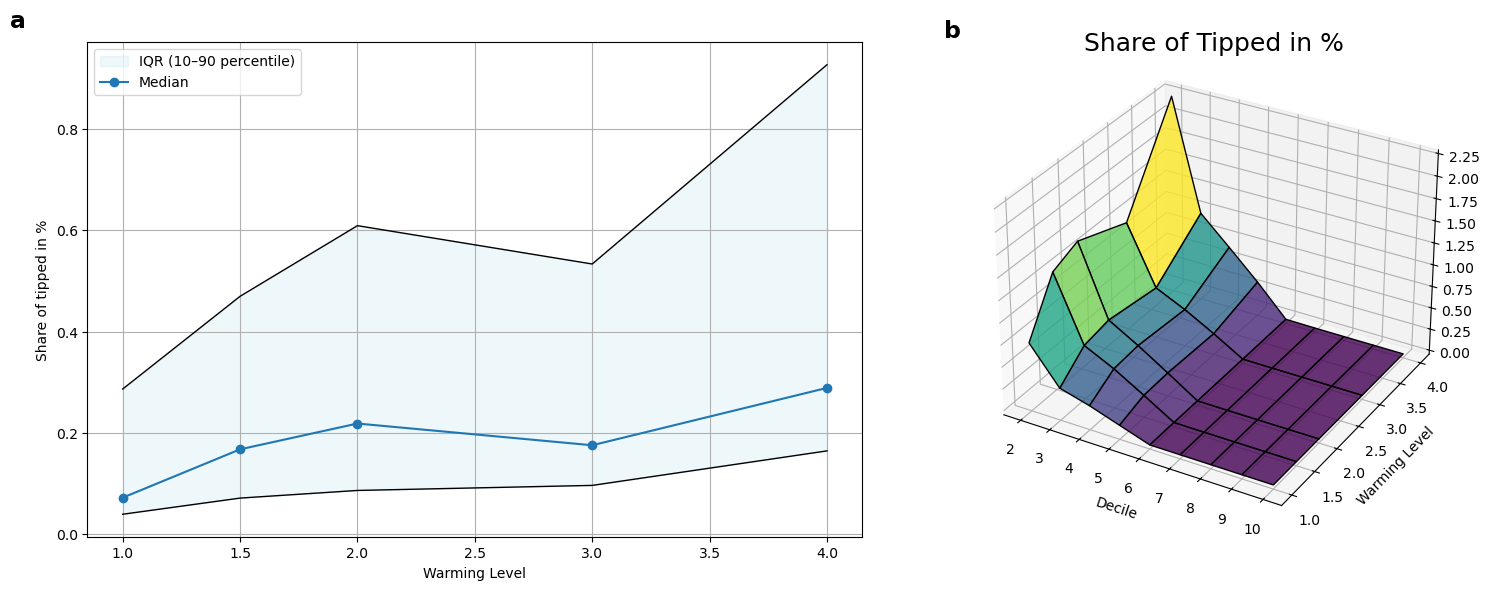

In [187]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16,6))

# -----------------------------
# LEFT PLOT: line + IQR band
# -----------------------------
ax1 = fig.add_subplot(1, 2, 1)

# Fill IQR band
ax1.fill_between(
    agg["wl_float"],
    agg_25["share_tipped"]*100-10,
    agg_75["share_tipped"]*100-10,
    alpha=0.2,
    color="lightblue",
    label="IQR (10–90 percentile)"
)

# Add subplot label
ax1.text(-0.1, 1.02, "a", transform=ax1.transAxes,
         fontsize=17, fontweight="bold", va="bottom")

# Main line
ax1.plot(agg["wl_float"], agg["share_tipped"]*100-10, marker='o', label="Median")

# 25th & 75th lines (thin)
ax1.plot(agg_25["wl_float"], agg_25["share_tipped"]*100-10, color="black", linewidth=1)
ax1.plot(agg_75["wl_float"], agg_75["share_tipped"]*100-10, color="black", linewidth=1)

ax1.set_xlabel("Warming Level")
ax1.set_ylabel("Share of tipped in %")
#ax1.set_title("Share of Tipped per Warming Level")
ax1.grid(True)
ax1.legend()

# -----------------------------
# RIGHT PLOT: 3D surface
# -----------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
fig.text(0.58, 0.93, "b", fontsize=17, fontweight="bold")
ax2.plot_surface(decile_grid, wl_grid, share_grid*100,
                 cmap='viridis', edgecolor='k', alpha=0.8)

ax2.set_xlabel('Decile')
ax2.set_ylabel('Warming Level')
#ax2.set_zlabel('Mean share of tipped')
ax2.set_title('Share of Tipped in %', fontsize= 18, y = 1.05)


plt.tight_layout()
plt.show()

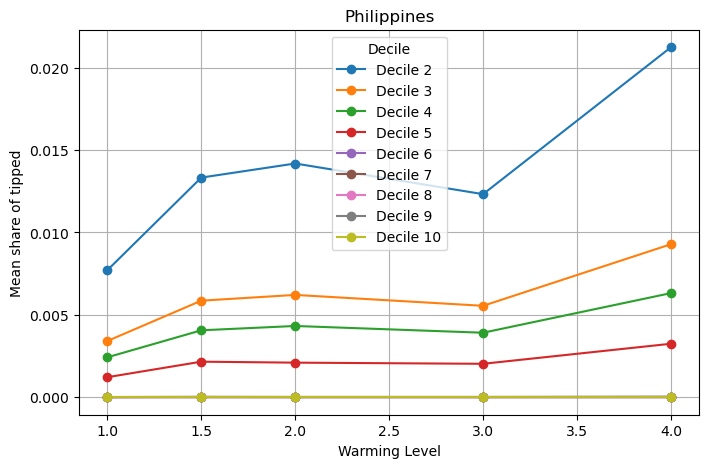

In [131]:
# Convert wl to float and scale
tipped_decile["wl_float"] = tipped_decile["wl"].astype(float) / 10

# Filter deciles >= 2
tipped_decile_filtered = tipped_decile[tipped_decile["decile"] >= 2]

# Aggregate by decile and wl taking mean
agg = tipped_decile_filtered.groupby(["decile", "wl_float"])[["tipped", "not_tipped"]].mean().reset_index()

# Compute share of tipped
agg["share_tipped"] = agg["tipped"] / (agg["tipped"] + agg["not_tipped"])

# 2D line plot: one line per decile
plt.figure(figsize=(8,5))
for decile in sorted(agg["decile"].unique()):
    subset = agg[agg["decile"] == decile]
    plt.plot(subset["wl_float"], subset["share_tipped"], marker='o', label=f"Decile {decile}")

plt.xlabel("Warming Level")
plt.ylabel("Mean share of tipped")
plt.title("Philippines")
plt.legend(title="Decile")
plt.grid(True)
plt.savefig('/home/insauer/projects/hhrm/projects/TipESM/data/final_plots/PHL/tipped_decile.png')